**Capítulo 1 – O Cenário do Aprendizado de Máquina**

*Este notebook contém uma adaptação prática dos exemplos de código do Capítulo 1 do livro "Hands-On Machine Learning". Exploramos a Regressão Linear e o K-Nearest Neighbors (KNN) na prática para prever a satisfação de vida com base no PIB per capita dos países.*

*Fique à vontade para analisar e analisar o código neste notebook. A parte de manipulação de dados serve para prepararmos nossa própria base `.csv` baixando direto das fontes reais, antes de começarmos o treinamento em si!*

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/01_the_machine_learning_landscape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/01_the_machine_learning_landscape.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Configuração

Este projeto requer Python 3.7 ou superior:

In [1]:
import sys

assert sys.version_info >= (3, 7)

Scikit-Learn ≥1.0.1 é necessário:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Vamos definir os tamanhos de fonte padrão para plotar belas figuras:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Tornar a saída deste notebook estável entre execuções:

In [4]:
import numpy as np

np.random.seed(42)

# Exemplo de código 1-1

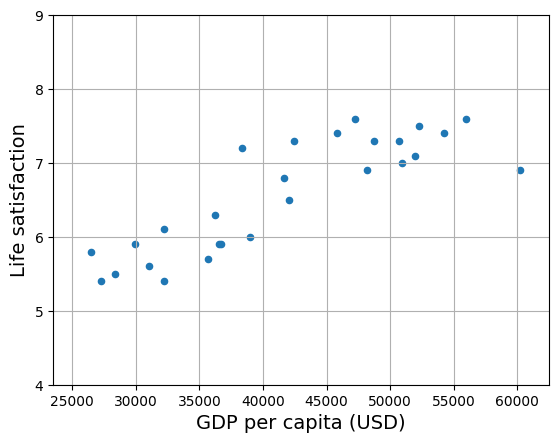

[[6.30165767]]


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# Baixar e preparar os dados
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")
X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values

# Visualizar os dados
lifesat.plot(kind='scatter', grid=True,
             x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.show()

# Selecionar um modelo linear
model = LinearRegression()

# Treinar o modelo
model.fit(X, y)

# Fazer uma previsão para Chipre
X_new = [[37_655.2]]  # PIB per capita do Chipre em 2020
print(model.predict(X_new)) # saída [[6.30165767]]

Substituir o modelo de Regressão Linear pela regressão de k-Vizinhos Mais Próximos (neste exemplo, k = 3) no código anterior é tão simples quanto substituir estas duas linhas:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

por estas duas:

```python
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=3)
```

In [6]:
# Selecionar o modelo de regressão 3-k-Vizinhos Mais Próximos
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=3)

# Treinar o modelo
model.fit(X, y)

# Fazer uma previsão para Chipre
print(model.predict(X_new)) # saída [[6.33333333]]


[[6.33333333]]


# Gerando os dados e as figuras — pode pular

Este é o código que usei para gerar o dataset `lifesat.csv`. Você pode pular isso com segurança.

Criar uma função para salvar as figuras:

In [9]:
from pathlib import Path

# Onde salvar as figuras
IMAGES_PATH = Path() / "images" / "fundamentals"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Carregar e preparar os dados de satisfação de vida

Para criar `lifesat.csv`, baixei os dados do Índice Vida Melhor (Better Life Index - BLI) do [site da OCDE](http://stats.oecd.org/index.aspx?DataSetCode=BLI) (para obter a Satisfação de Vida de cada país) e os dados do PIB per capita do Banco Mundial do [OurWorldInData.org](https://ourworldindata.org/grapher/gdp-per-capita-worldbank). Os dados do BLI estão em `datasets/lifesat/oecd_bli.csv` (dados de 2020), e os dados do PIB per capita estão em `datasets/lifesat/gdp_per_capita.csv` (dados até 2020).

Se você quiser pegar as versões mais recentes, fique à vontade para fazê-lo. No entanto, pode haver algumas mudanças (por exemplo, nos nomes das colunas ou países diferentes com dados ausentes), então esteja preparado para ter que ajustar o código.

In [10]:
# Importar a biblioteca para downloads web
import urllib.request

# Criar o diretório de destino caso não exista
datapath = Path() / "datasets" / "lifesat"
datapath.mkdir(parents=True, exist_ok=True)

# Baixar os arquivos CSV do repositório
data_root = "https://github.com/ageron/data/raw/main/"
for filename in ("oecd_bli.csv", "gdp_per_capita.csv"):
    if not (datapath / filename).is_file():
        print("Downloading", filename)
        url = data_root + "lifesat/" + filename
        urllib.request.urlretrieve(url, datapath / filename)


In [23]:
# Carregar os arquivos CSV na memória como DataFrames do Pandas
oecd_bli = pd.read_csv(datapath / "oecd_bli.csv")
gdp_per_capita = pd.read_csv(datapath / "gdp_per_capita.csv")


Pré-processar os dados do PIB per capita para manter apenas o ano de 2020:

In [24]:
gdp_year = 2020
gdppc_col = "GDP per capita (USD)"
lifesat_col = "Life satisfaction"

gdp_per_capita = gdp_per_capita[gdp_per_capita["Year"] == gdp_year]
gdp_per_capita = gdp_per_capita.drop(["Code", "Year"], axis=1)
gdp_per_capita.columns = ["Country", gdppc_col]
gdp_per_capita.set_index("Country", inplace=True)

gdp_per_capita.head()

,GDP per capita (USD)
Country,
Afghanistan,1978.961579
Africa Eastern and Southern,3387.594670
Africa Western and Central,4003.158913
Albania,13295.410885
Algeria,10681.679297


Pré-processar os dados da OCDE para manter apenas a coluna `Life satisfaction`:

In [25]:
oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")

oecd_bli.head()

Indicator,Air pollution,Dwellings without basic facilities,Educational attainment,Employees working very long hours,Employment rate,Feeling safe walking alone at night,Homicide rate,Household net adjusted disposable income,Household net wealth,Housing expenditure,...,Personal earnings,Quality of support network,Rooms per person,Self-reported health,Stakeholder engagement for developing regulations,Student skills,Time devoted to leisure and personal care,Voter turnout,Water quality,Years in education
Country,,,,,,,,,,,,,,,,,,,,,
Australia,5.0,NaN,81.0,13.04,73.0,63.5,1.1,32759.0,427064.0,20.0,...,49126.0,95.0,NaN,85.0,2.7,502.0,14.35,91.0,93.0,21.0
Austria,16.0,0.9,85.0,6.66,72.0,80.6,0.5,33541.0,308325.0,21.0,...,50349.0,92.0,1.6,70.0,1.3,492.0,14.55,80.0,92.0,17.0
Belgium,15.0,1.9,77.0,4.75,63.0,70.1,1.0,30364.0,386006.0,21.0,...,49675.0,91.0,2.2,74.0,2.0,503.0,15.70,89.0,84.0,19.3
Brazil,10.0,6.7,49.0,7.13,61.0,35.6,26.7,NaN,NaN,NaN,...,NaN,90.0,NaN,NaN,2.2,395.0,NaN,79.0,73.0,16.2
Canada,7.0,0.2,91.0,3.69,73.0,82.2,1.3,30854.0,423849.0,22.0,...,47622.0,93.0,2.6,88.0,2.9,523.0,14.56,68.0,91.0,17.3


Agora vamos fundir os dados de satisfação de vida com os do PIB per capita, mantendo apenas estas duas colunas:

In [26]:
# Mesclar os dois DataFrames baseando-se no índice (País)
full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                              left_index=True, right_index=True)

# Ordenar pelo PIB per capita
full_country_stats.sort_values(by=gdppc_col, inplace=True)

# Preencher o DataFrame resultante mantendo apenas as colunas relevantes
full_country_stats = full_country_stats[[gdppc_col, lifesat_col]]

# Exibir as primeiras linhas
full_country_stats.head()


,GDP per capita (USD),Life satisfaction
Country,,
South Africa,11466.189672,4.7
Colombia,13441.492952,6.3
Brazil,14063.982505,6.4
Mexico,17887.750736,6.5
Chile,23324.524751,6.5


Para ilustrar o risco de sobreajuste (overfitting), uso apenas parte dos dados na maioria das figuras (todos os países com um PIB per capita entre `min_gdp` e `max_gdp`). Mais adiante no capítulo, revelo os países ausentes e mostro que eles não seguem a mesma tendência linear de forma alguma.

In [27]:
min_gdp = 23_500
max_gdp = 62_500

country_stats = full_country_stats[(full_country_stats[gdppc_col] >= min_gdp) &
                                   (full_country_stats[gdppc_col] <= max_gdp)]
country_stats.head()

,GDP per capita (USD),Life satisfaction
Country,,
Russia,26456.387938,5.8
Greece,27287.083401,5.4
Turkey,28384.987785,5.5
Latvia,29932.493910,5.9
Hungary,31007.768407,5.6


In [28]:
country_stats.to_csv(datapath / "lifesat.csv")
full_country_stats.to_csv(datapath / "lifesat_full.csv")

### Explorando Visualmente os Dados

Vamos criar um gráfico de dispersão (scatter plot) para visualizar a relação geral entre o **PIB per capita** e a **Satisfação de Vida** nos países que filtramos. Isso nos ajuda a identificar à primeira vista se existe alguma tendência (linear ou não) nos dados.

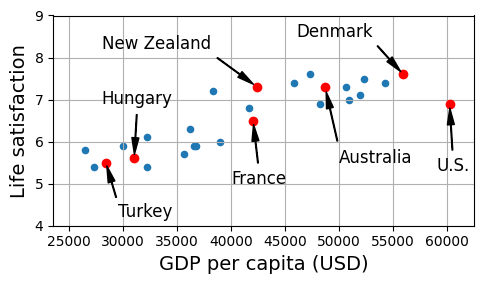

In [45]:
# Plotar o gráfico de dispersão (scatter plot) dos dados selecionados
country_stats.plot(kind='scatter', figsize=(5, 3), grid=True,
                   x=gdppc_col, y=lifesat_col)

# Definir os limites dos eixos
min_life_sat = 4
max_life_sat = 9

# Mapear anotações textuais específicas para destacar alguns países no gráfico
position_text = {
    "Turkey": (29_500, 4.2),
    "Hungary": (28_000, 6.9),
    "France": (40_000, 5),
    "New Zealand": (28_000, 8.2),
    "Australia": (50_000, 5.5),
    "United States": (59_000, 5.3),
    "Denmark": (46_000, 8.5)
}

# Inserir anotações e setas no gráfico para evidenciar os países listados
for country, pos_text in position_text.items():
    pos_data_x = country_stats[gdppc_col].loc[country]
    pos_data_y = country_stats[lifesat_col].loc[country]
    country = "U.S." if country == "United States" else country
    plt.annotate(country, xy=(pos_data_x, pos_data_y),
                 xytext=pos_text, fontsize=12,
                 arrowprops=dict(facecolor='black', width=0.5,
                                 shrink=0.08, headwidth=5))
    plt.plot(pos_data_x, pos_data_y, "ro") # "ro" plota a bolinha vermelha

# Definir a escala visível
plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])

# Salvar e mostrar a figura
save_fig('money_happy_scatterplot')
plt.show()


In [30]:
highlighted_countries = country_stats.loc[list(position_text.keys())]
highlighted_countries[[gdppc_col, lifesat_col]].sort_values(by=gdppc_col)

,GDP per capita (USD),Life satisfaction
Country,,
Turkey,28384.987785,5.5
Hungary,31007.768407,5.6
France,42025.617373,6.5
New Zealand,42404.393738,7.3
Australia,48697.837028,7.3
Denmark,55938.212809,7.6
United States,60235.728492,6.9


### Ajustando os Parâmetros do Modelo (Na Mão)

Antes de deixarmos a máquina aprender os melhores parâmetros, o código abaixo visualiza como diferentes valores manuais afetam a reta resultante. Cada reta (verde, azul, vermelha) representa uma tentativa com parâmetros (pesos) diferentes.

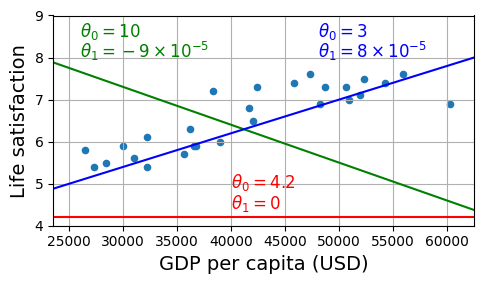

In [31]:
# Reiniciar o plot do gráfico base
country_stats.plot(kind='scatter', figsize=(5, 3), grid=True,
                   x=gdppc_col, y=lifesat_col)

# Criar uma área numérica (espaço linear) para traçar as retas
X = np.linspace(min_gdp, max_gdp, 1000)

# Traçar Reta 1 (Vermelha)
w1, w2 = 4.2, 0
plt.plot(X, w1 + w2 * 1e-5 * X, "r")
plt.text(40_000, 4.9, fr"$\theta_0 = {w1}$", color="r")
plt.text(40_000, 4.4, fr"$\theta_1 = {w2}$", color="r")

# Traçar Reta 2 (Verde)
w1, w2 = 10, -9
plt.plot(X, w1 + w2 * 1e-5 * X, "g")
plt.text(26_000, 8.5, fr"$\theta_0 = {w1}$", color="g")
plt.text(26_000, 8.0, fr"$\theta_1 = {w2} \times 10^{{-5}}$", color="g")

# Traçar Reta 3 (Azul)
w1, w2 = 3, 8
plt.plot(X, w1 + w2 * 1e-5 * X, "b")
plt.text(48_000, 8.5, fr"$\theta_0 = {w1}$", color="b")
plt.text(48_000, 8.0, fr"$\theta_1 = {w2} \times 10^{{-5}}$", color="b")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])
save_fig('tweaking_model_params_plot')
plt.show()


### Treinamento: Descobrindo o 'Melhor Ajuste' (Best Fit)

Agora utilizamos o `LinearRegression` do Scikit-Learn. A máquina encontra a reta ideal automaticamente minimizando a distância entre as predições e os pontos reais (função de custo).

In [32]:
# Importar o pacote de modelos lineares
from sklearn import linear_model

# Formatar as amostras como matrizes (necessário para o sklearn)
X_sample = country_stats[[gdppc_col]].values
y_sample = country_stats[[lifesat_col]].values

# Instanciar o modelo
lin1 = linear_model.LinearRegression()

# Executar o treinamento (fit) aos dados parciais
lin1.fit(X_sample, y_sample)

# Extrair os parâmetros gerados pelo treinamento
t0, t1 = lin1.intercept_[0], lin1.coef_.ravel()[0]

# Exibir os parâmetros ideais encontrados: Intercepto (theta 0) e Inclinação (theta 1)
print(f"θ0={t0:.2f}, θ1={t1:.2e}")


θ0=3.75, θ1=6.78e-05


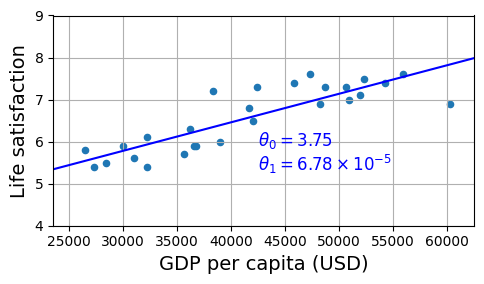

In [33]:
country_stats.plot(kind='scatter', figsize=(5, 3), grid=True,
                   x=gdppc_col, y=lifesat_col)

X = np.linspace(min_gdp, max_gdp, 1000)
plt.plot(X, t0 + t1 * X, "b")

plt.text(max_gdp - 20_000, min_life_sat + 1.9,
         fr"$\theta_0 = {t0:.2f}$", color="b")
plt.text(max_gdp - 20_000, min_life_sat + 1.3,
         fr"$\theta_1 = {t1 * 1e5:.2f} \times 10^{{-5}}$", color="b")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])

save_fig('best_fit_model_plot')
plt.show()

In [34]:
# Separar o valor independente (PIB per capita) de Chipre
cyprus_gdp_per_capita = gdp_per_capita[gdppc_col].loc["Cyprus"]
cyprus_gdp_per_capita


np.float64(37655.1803457421)

In [35]:
cyprus_predicted_life_satisfaction = lin1.predict([[cyprus_gdp_per_capita]])[0, 0]
cyprus_predicted_life_satisfaction

np.float64(6.301656332738056)

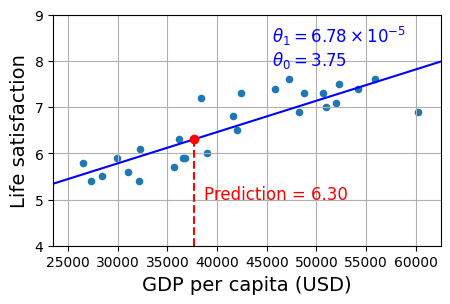

In [36]:
country_stats.plot(kind='scatter', figsize=(5, 3), grid=True,
                   x=gdppc_col, y=lifesat_col)

X = np.linspace(min_gdp, max_gdp, 1000)
plt.plot(X, t0 + t1 * X, "b")

plt.text(min_gdp + 22_000, max_life_sat - 1.1,
         fr"$\theta_0 = {t0:.2f}$", color="b")
plt.text(min_gdp + 22_000, max_life_sat - 0.6,
         fr"$\theta_1 = {t1 * 1e5:.2f} \times 10^{{-5}}$", color="b")

plt.plot([cyprus_gdp_per_capita, cyprus_gdp_per_capita],
         [min_life_sat, cyprus_predicted_life_satisfaction], "r--")
plt.text(cyprus_gdp_per_capita + 1000, 5.0,
         fr"Prediction = {cyprus_predicted_life_satisfaction:.2f}", color="r")
plt.plot(cyprus_gdp_per_capita, cyprus_predicted_life_satisfaction, "ro")

plt.axis([min_gdp, max_gdp, min_life_sat, max_life_sat])

plt.show()

### Dados Ausentes e o Risco de Ser Enganado pela Amostra

As retas anteriores foram feitas em dados selecionados. Mas o que acontece se considerarmos **todos** os países? Veremos que a relação linear começa a ruir quando inserimos casos extremos na amostra (países muito pobres, ou muito ricos).

In [37]:
# Separar a parte dos dados originais que excluímos intencionalmente no início
missing_data = full_country_stats[(full_country_stats[gdppc_col] < min_gdp) |
                                  (full_country_stats[gdppc_col] > max_gdp)]
missing_data


,GDP per capita (USD),Life satisfaction
Country,,
South Africa,11466.189672,4.7
Colombia,13441.492952,6.3
Brazil,14063.982505,6.4
Mexico,17887.750736,6.5
Chile,23324.524751,6.5
Norway,63585.903514,7.6
Switzerland,68393.306004,7.5
Ireland,89688.956958,7.0
Luxembourg,110261.157353,6.9


In [38]:
position_text_missing_countries = {
    "South Africa": (20_000, 4.2),
    "Colombia": (6_000, 8.2),
    "Brazil": (18_000, 7.8),
    "Mexico": (24_000, 7.4),
    "Chile": (30_000, 7.0),
    "Norway": (51_000, 6.2),
    "Switzerland": (62_000, 5.7),
    "Ireland": (81_000, 5.2),
    "Luxembourg": (92_000, 4.7),
}

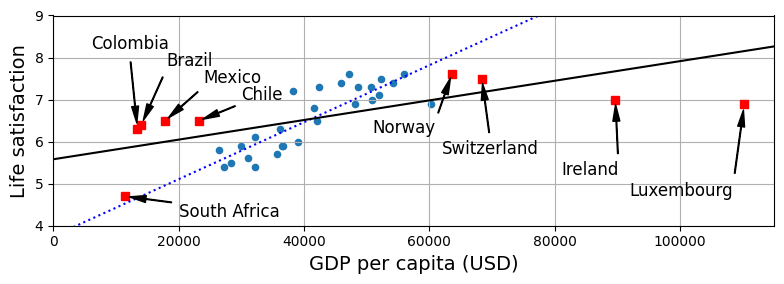

In [40]:
# Plotar todos os países (base principal + ausentes)
full_country_stats.plot(kind='scatter', figsize=(8, 3),
                        x=gdppc_col, y=lifesat_col, grid=True)

# Destacar os países que estavam ausentes visualmente no gráfico (quadrados vermelhos 'rs')
for country, pos_text in position_text_missing_countries.items():
    pos_data_x, pos_data_y = missing_data.loc[country]
    plt.annotate(country, xy=(pos_data_x, pos_data_y),
                 xytext=pos_text, fontsize=12,
                 arrowprops=dict(facecolor='black', width=0.5,
                                 shrink=0.08, headwidth=5))
    plt.plot(pos_data_x, pos_data_y, "rs")

# Desenhar (em azul tracejado) o modelo treinado apenas sobre os dados parciais
X = np.linspace(0, 115_000, 1000)
plt.plot(X, t0 + t1 * X, "b:")

# Treinar um novo modelo Linear Regression com base em *TODOS* os países
lin_reg_full = linear_model.LinearRegression()
Xfull = np.c_[full_country_stats[gdppc_col]]
yfull = np.c_[full_country_stats[lifesat_col]]
lin_reg_full.fit(Xfull, yfull)

# Extrair os parâmetros e traçar (em preto sólido) a reta aprendida nos dados completos
t0full, t1full = lin_reg_full.intercept_[0], lin_reg_full.coef_.ravel()[0]
X = np.linspace(0, 115_000, 1000)
plt.plot(X, t0full + t1full * X, "k")

plt.axis([0, 115_000, min_life_sat, max_life_sat])
save_fig('representative_training_data_scatterplot')
plt.show()


### Sobreajuste (Overfitting) em Modelos Complexos

Se um modelo simples (reta) falhou, poderíamos tentar um incrivelmente complexo (como um Polinômio flexível de grau 10). O problema é que o modelo tentará "decorar" os dados de treinamento, criando curvas absurdas, garantindo de que não generalizará para novos dados.

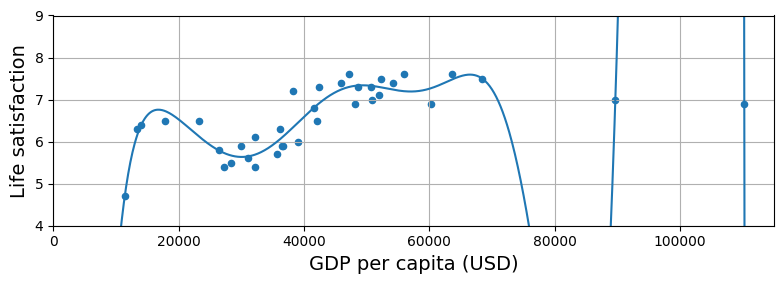

In [41]:
# Importar bibliotecas para transformações matemáticas profundas e processamento encadeado
from sklearn import preprocessing
from sklearn import pipeline

full_country_stats.plot(kind='scatter', figsize=(8, 3),
                        x=gdppc_col, y=lifesat_col, grid=True)

# Criar características polinomiais (Grau 10) garantindo imensa flexibilidade para o modelo
poly = preprocessing.PolynomialFeatures(degree=10, include_bias=False)

# Escalar os atributos garante que valores exponenciais altos não causem instabilidade
scaler = preprocessing.StandardScaler()

# O Estimador base ainda é a regressão linear, mas atuará sob as características polinomiais
lin_reg2 = linear_model.LinearRegression()

# Criar e treinar (fit) o pipeline aglomerando todas as etapas de transformação e modelo
pipeline_reg = pipeline.Pipeline([
    ('poly', poly),
    ('scal', scaler),
    ('lin', lin_reg2)])
pipeline_reg.fit(Xfull, yfull)

# Realizar a predição pontilhada (curva flexível construída) e sobrepor no gráfico
curve = pipeline_reg.predict(X[:, np.newaxis])
plt.plot(X, curve)

plt.axis([0, 115_000, min_life_sat, max_life_sat])
save_fig('overfitting_model_plot')
plt.show()


In [42]:
w_countries = [c for c in full_country_stats.index if "W" in c.upper()]
full_country_stats.loc[w_countries][lifesat_col]

Country
New Zealand    7.3
Sweden         7.3
Norway         7.6
Switzerland    7.5
Name: Life satisfaction, dtype: float64

In [43]:
all_w_countries = [c for c in gdp_per_capita.index if "W" in c.upper()]
gdp_per_capita.loc[all_w_countries].sort_values(by=gdppc_col)

,GDP per capita (USD)
Country,
Malawi,1486.778248
Rwanda,2098.710362
Zimbabwe,2744.690758
Africa Western and Central,4003.158913
Papua New Guinea,4101.218882
Lower middle income,6722.809932
Eswatini,8392.717564
Low & middle income,10293.855325
Arab World,13753.707307


### Regularização: Controlando Modelos Teimosos

A Regressão *Ridge* força os pesos do modelo a serem tão pequenos quanto possível. Esse freio e contrapeso evita que a reta tente agradar cada anomalia ou "ruído", resultando num modelo com viés maior, mas que generaliza de maneira robusta (visto que ele ignora parcialmente dados problemáticos ou isolados no treinamento local).

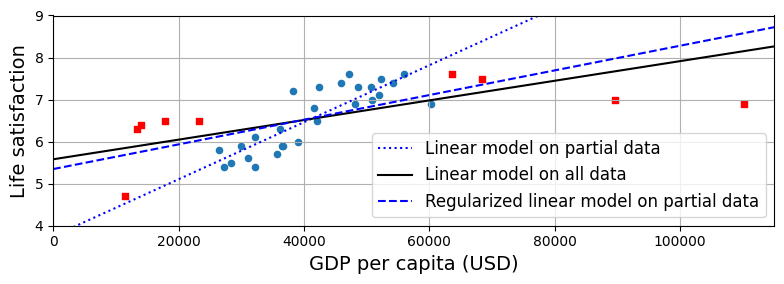

In [44]:
# Exibir scatterplot juntando dados originais (bolinhas) e novos dados 'ruido' ou extremos (quadrados vermelhos)
country_stats.plot(kind='scatter', x=gdppc_col, y=lifesat_col, figsize=(8, 3))
missing_data.plot(kind='scatter', x=gdppc_col, y=lifesat_col,
                  marker="s", color="r", grid=True, ax=plt.gca())

# Traçar a reta que havíamos criado com os dados parciais em formato pontilhado azul
X = np.linspace(0, 115_000, 1000)
plt.plot(X, t0 + t1*X, "b:", label="Linear model on partial data")

# Traçar a reta do modelo distorcido treinado com os dados totais em preto liso
plt.plot(X, t0full + t1full * X, "k-", label="Linear model on all data")

# Treinar um MODELO RIDGE apenas com os dados parciais. O hiperparâmetro alpha dita "quão dura" será a penalização
ridge = linear_model.Ridge(alpha=10**9.5)
X_sample = country_stats[[gdppc_col]]
y_sample = country_stats[[lifesat_col]]
ridge.fit(X_sample, y_sample)

# Extrair os parâmetros penalizados (amansados pelo modelo Ridge) e desenhá-los (linhas tracejadas azuis)
t0ridge, t1ridge = ridge.intercept_[0], ridge.coef_.ravel()[0]
plt.plot(X, t0ridge + t1ridge * X, "b--",
         label="Regularized linear model on partial data")

# Exibir a legenda
plt.legend(loc="lower right")

plt.axis([0, 115_000, min_life_sat, max_life_sat])
save_fig('ridge_model_plot')
plt.show()
